# Stochastic Volatility Inspired (SVI)
## Portion by: Aurora Hiveley

Stochastic Volatility Inspired (SVI) is a stochastic volatility model widely used to calibrate the implied volatility smile. A stochastic volatility model treats the variance of a stochastic process as a quantity which also varies randomly over time, in contrast to Black-Scholes's (inaccurate) assumption of constant volatility. SVI was originally created by Merrill Lynch in 1999 using the principles of the Heston model, and it now has many extensions including SSVI and SVI-JW. Researchers continue to refine SVI to better protect against arbitrage while maintaining the flexibility of the model. Due to its popularity at real-world options desks, this model will act as the "baseline" for our project when comparing the performance of other models.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import yfinance as yf


from scipy.stats import normaltest
from statsmodels.stats.diagnostic import acorr_ljungbox

sns.set_style('darkgrid')

We import the processed data, which spans the entirety of 2023 for 6 S&P funds: AAPL, NVDA, QQQ, SLV, SPX, and TSLA.

In [2]:
from google.colab import files
df = files.upload()

Saving surface_all.parquet to surface_all.parquet


In [3]:
df = pd.read_parquet("surface_all.parquet")

We will use only 80% of the data points in the data set on a given day to train the SVI model and construct a parametrization. Then, the model will be analyzed by checking its accuracy against the missing 20% of the data points. We will use the following to separate our data frame into two pieces: the holdout frame, and the remaining data points.

In [4]:
def make_holdout(frame, frac, min_vis, seed):
  rng = np.random.default_rng(seed)
  hold = pd.Series(False, index=frame.index)
  for _, sl in frame.groupby(["ticker", "quote_date", "expire_date"]):
    n = len(sl)
    n_hold = min(int(round(frac * n)), max(0, n - min_vis))
    if n_hold > 0:
      hold.loc[rng.choice(sl.index.values, size=n_hold, replace=False)] = True
  return hold

In [5]:
## craft the holdout dataset
# tickers: 'AAPL', 'NVDA', 'QQQ', 'SLV', 'SPX', 'TSLA'
TICKER = "SPX"

df = df[df["ticker"] == TICKER].copy().reset_index(drop=True)
print(f"{TICKER}: {len(df)} quotes over {df['quote_date'].nunique()} days")

HOLDOUT_FRAC, MIN_VISIBLE, SPLIT_SEED = 0.20, 6, 0

df["is_holdout"] = make_holdout(df, HOLDOUT_FRAC, MIN_VISIBLE, SPLIT_SEED)

lvl = (df[~df["is_holdout"]].groupby(["ticker", "quote_date"])["iv"].median().rename("day_level").reset_index())
df = df.merge(lvl, on=["ticker", "quote_date"], how="left")
df["day_level"] = df["day_level"].fillna(df["iv"].median())

n_vis, n_hold = (~df["is_holdout"]).sum(), df["is_holdout"].sum()

SPX: 1462299 quotes over 249 days


The SVI model uses the log-moneyness, which in turn is a function of strike price $K$ and forward $F$ where $F = S e^{rt}$. There are multiple parametrizations of SVI, but the most commonly used for its versatility is the raw parametrization:  
$$\delta(k) = a + b \left( \rho(k-m) + \sqrt{(k-m)^2 + \sigma^2} \right)$$

Here, the input $k$ is the log-moneyness $k = \log(K/F)$, and the parameters $a$, $b$, $\rho$, $m$, and $\sigma$ all vary the shape of the implied volatility smile as follows. Note that $\sigma$ is **not** volaility or variance, but a separate parameter (in spite of its similar name.)

* $a$: Vertical translation of the curve
* $b$: Tightness of the curve, or the angle between put and call wings
* $\rho$: Counterclockwise rotation of the smile
* $m$: Horizontal translation of the curve
* $\sigma$: At-the-money curvature

To calibrate our parameters to a given data set, we will perform a least squares fit using the initial parameter guess:

- $a = 0.5*\min\{$ Total Variance$\}$
- $b = 0.1$
- $\rho = -0.5$
- $m = 0.1$
- $\sigma = 0.1$

The least squares fit is a function built in to the `optimize` package of the `scipy` library.


In [6]:
from scipy.optimize import least_squares
np.random.seed(0)

def SVI_model(frame):
  '''
  SVI Model for Dataframe

  Inputs:
  frame: data frame

  Returns:
  Vector of values output by parametrized SVI using the input log moneyness column from data frame
  '''

  x = frame['log_moneyness'] # independent variables
  y = frame['iv']  # dependent variables
  min_total_var = min(frame['total_var'])

  # compute parameters for SVI based on refined data
  c = parametrize_SVI(x,y,min_total_var)

  return SVI_raw(x,c[0],c[1],c[2],c[3],c[4])



def parametrize_SVI(x,y,min_total_var):
  '''
  SVI Parametrization
  Calculates the optimized parametrization of raw SVI by minimizing least squares

  Inputs:
  x: log moneyness vector
  y: implied volatility vector
  min_total_var: minimum total variance over all data points (used for initial guess)

  Returns:
  Vector of fit parameters [a,b,rho,m,sigma] for raw SVI
  '''

  def residuals(c, x, y):
      # Return residual = fit - observed
      return (SVI_raw(x,c[0],c[1],c[2],c[3],c[4]) - y)

  # initial parameter guess
  c0 = np.array([0.5*min_total_var, 0.1, -0.5, 0.1, 0.1])

  # Compute solution providing initial guess c0, x input, and y input
  sol = least_squares(residuals, c0, args=(x,y))
  return(sol.x)


def SVI_raw(lm,a,b,rho,m,sigma):
    '''
    Raw SVI Model
    Inputs:
    x: log moneyness

    a: vertical translation
    b: tightness, or angle between put and call wings
    rho: counterclockwise rotation of the smile
    m: horizontal translation
    sigma: at-the-money curvature (NOTE: NOT VOLATILITY! DIFFERENT SIGMA)

    Returns:
    SVI prediction
    '''
    return a + b*(rho*(lm-m) + np.sqrt((lm-m)**2 + sigma**2))

Here, we construct several implied volatility curves against a scatterplot of the datapoints used. This gives us a visual representation of our fit for an assortment of days.

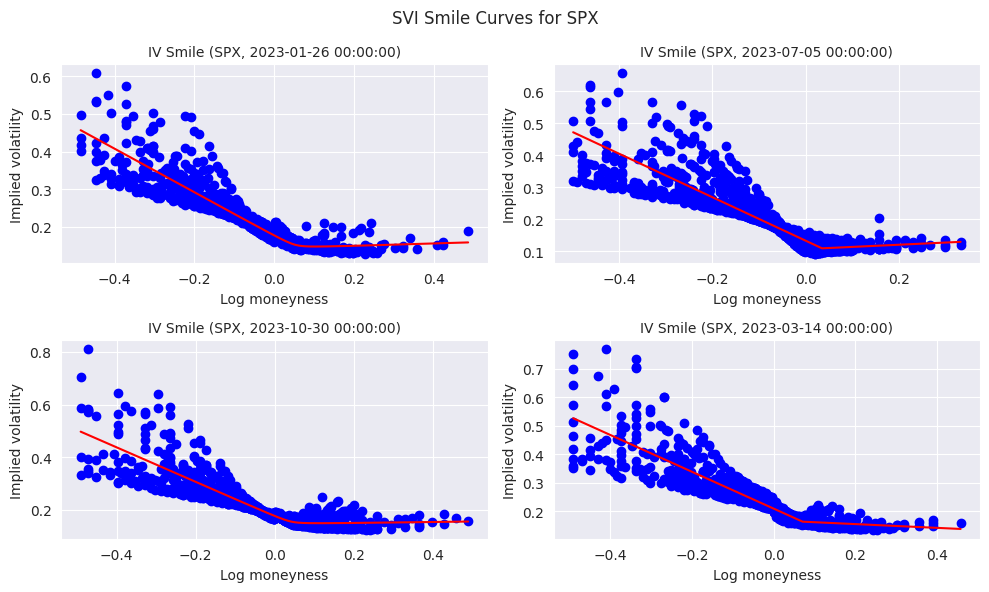

In [61]:
fig, ax = plt.subplots(2, 2, figsize=(10, 6))
samples = 4

dates = df["quote_date"].sample(n=samples, random_state=1)

for i,date in zip(range(samples),dates):
    # implied volatility smile curve
    frame = df[(df["is_holdout"] == True) & (df['quote_date']== date)]

    x = frame['log_moneyness'] # independent variables
    y = frame['iv']  # dependent variables
    ax.flat[i].scatter(x,y, color = 'blue')

    # reformat/sort the arrays so that matplotlib can handle it
    x1,y1 = zip(*sorted(zip(x, SVI_model(frame))))
    ax.flat[i].plot(x1,y1, label = 'SVI', color = 'red')

    ax.flat[i].set_title(f'IV Smile ({TICKER}, {date})', size = 10)
    ax.flat[i].set_xlabel('Log moneyness')
    ax.flat[i].set_ylabel('Implied volatility')

plt.suptitle(f"SVI Smile Curves for {TICKER}")
plt.tight_layout()

We also plot the implied volatility surface in 3-D, which plots the log-moneyness, the time to expiration, and the implied volatility all together.

/tmp/ipykernel_25089/3288601153.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


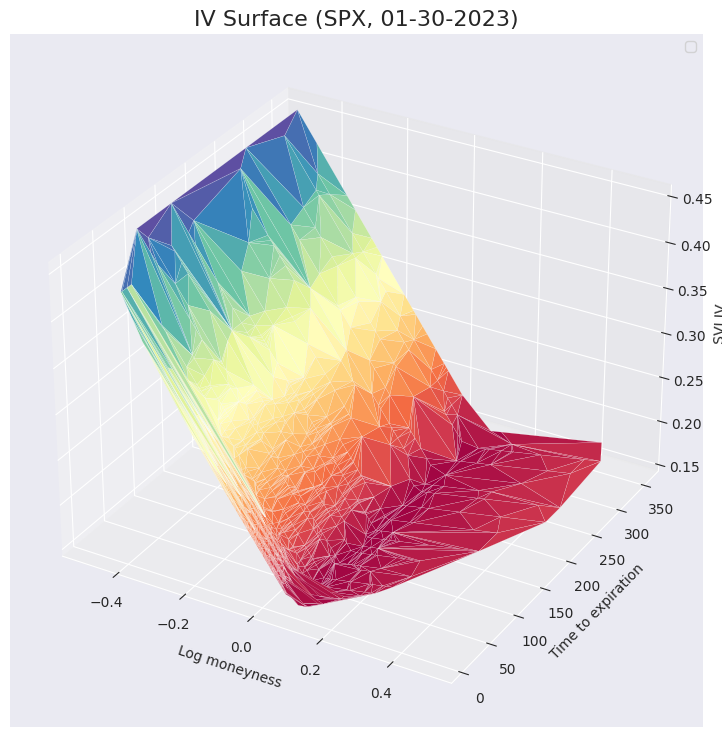

In [7]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize =(16, 9))

frame = df[(df["is_holdout"] == True) & (df['quote_date']== '2023-01-30')]

x = frame['log_moneyness']
y = frame['dte']

x,y,z = zip(*sorted(zip(x, y, SVI_model(frame))))

ax.plot_trisurf(x,y,z, linewidth = 0.1, cmap="Spectral")

plt.title('IV Surface (SPX, 01-30-2023)', size = 16)
ax.set_xlabel('Log moneyness')
ax.set_ylabel('Time to expiration')
ax.set_zlabel('SVI IV')
plt.legend()

plt.show()

To verify the accuracy of the model, we check the model's fit for the other 20% of the data points which were omitted from model training. This allows us to verify the model's stability.

In [30]:
from scipy.interpolate import interp1d

def mean_squared_residuals(df,date):
  frameT = df[(df["is_holdout"] == True) & (df['quote_date']== date)]
  frameF = df[(df["is_holdout"] == False) & (df['quote_date']== date)]

  # SVI interpolated into continuous function
  x,y = zip(*sorted(zip(frameT['log_moneyness'],SVI_model(frameT))))
  f = interp1d(x,y, fill_value="extrapolate")

  residues = f(frameF["log_moneyness"]) - frameF["iv"]
  N = len(frameF)

  # mean squares of residuals
  return (1/N)*np.sum((residues - np.mean(residues))**2)

In [33]:
# some example days:
samples = 7
dates = df["quote_date"].sample(n=samples, random_state=1)

for date in dates:
  print(f'Mean squared residuals from SVI for {TICKER} on {date}: ', mean_squared_residuals(df,date))

Mean squared residuals from SVI for SPX on 2023-01-26 00:00:00:  0.0010364128998196294
Mean squared residuals from SVI for SPX on 2023-07-05 00:00:00:  0.0018881725134900207
Mean squared residuals from SVI for SPX on 2023-10-30 00:00:00:  0.001407259244721717
Mean squared residuals from SVI for SPX on 2023-03-14 00:00:00:  0.0013210953325963894
Mean squared residuals from SVI for SPX on 2023-12-06 00:00:00:  0.0018141700186426
Mean squared residuals from SVI for SPX on 2023-04-21 00:00:00:  0.0009745147689786784
Mean squared residuals from SVI for SPX on 2023-11-10 00:00:00:  0.0021513047196676212
